# Preprocessing: pipeline effects on Yelp data

This notebook walks through the same stages as `run_preprocessing.ipynb` and shows **how values look** on raw vs processed data. Histograms use **multiple metrics per figure**; degenerate (single-value) columns are skipped.

**Prerequisite:** Run `run_preprocessing.ipynb` through Stage 7 so Parquet and `column_lineage.json` exist.


In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import importlib

from IPython.display import Markdown, display

from src.constants import PROCESSED_DIR
from src.preprocessing.column_lineage import read_column_lineage
from src.preprocessing.eda import (
    dataset_overview,
    duplicate_report_all,
    null_report,
    numeric_columns,
    numeric_describe,
)
from src.spark.load_data import load_dataset
import src.spark.pandas_sample as _pandas_sample_mod
importlib.reload(_pandas_sample_mod)
to_pandas_sample = _pandas_sample_mod.to_pandas_sample
from src.spark.session import create_spark_session

sns.set_style("whitegrid")
%matplotlib inline


In [54]:
spark = create_spark_session("preprocessing_comparison")

TABLE_NAMES = ["business", "review", "user", "checkin", "tip", "photo"]

raw = {name: load_dataset(spark, name) for name in TABLE_NAMES}

processed = {}
all_exist = all((PROCESSED_DIR / n).exists() for n in TABLE_NAMES)
if all_exist:
    for name in TABLE_NAMES:
        processed[name] = spark.read.parquet(str(PROCESSED_DIR / name))
else:
    print("Some processed paths missing - running preprocess_all (run run_preprocessing.ipynb to write Parquet)")
    from src.preprocessing import preprocess_all
    processed = preprocess_all(spark, load_raw=True)

---
## 1. Dataset overview and description

**For your report:** the Yelp Academic dataset has entities `business`, `review`, `user`, plus `checkin`, `tip`, `photo`. Tables join on `business_id`, `user_id`. Below: row and column counts for raw JSON vs processed Parquet.


In [59]:
TABLE_ORDER = ["business", "review", "user", "checkin", "tip", "photo"]
raw_ordered = {k: raw[k] for k in TABLE_ORDER if k in raw}
processed_ordered = {k: processed[k] for k in TABLE_ORDER if k in processed}

print("=== Raw (JSON) ===")
display(dataset_overview(raw_ordered))
print("=== Processed (Parquet) ===")
display(dataset_overview(processed_ordered))


=== Raw (JSON) ===


,table,rows,columns
0,business,150346,14
1,review,6990280,9
2,user,1987897,22
3,checkin,131930,2
4,tip,908915,5
5,photo,200100,4


=== Processed (Parquet) ===


,table,rows,columns
0,business,150346,51
1,review,6990280,11
2,user,1987897,24
3,checkin,131930,6
4,tip,908836,8
5,photo,200098,4


,table,rows,columns
0,business,150346,51
1,review,6990280,11
2,user,1987897,24
3,checkin,131930,6
4,tip,908836,8
5,photo,200098,4


---
## 2. Numeric features — statistics and analysis

Below: Spark `summary()` on numeric columns only. Each result is labeled **Table 2.1** … **Table 2.12** (raw then processed for each entity, in order: business → review → user → checkin → tip → photo). For `review` we use a sample (`NUMERIC_SAMPLE=0.05`) to save time; set `1.0` for a full report.

After **transform**, min–max scaling maps most numeric metrics into [0, 1] (except excluded fields and date-derived columns).

The next subsection shows **box-plot summaries** for a reduced subset of numeric columns (skipping every other column) that exists in both raw and processed (same name), one figure per plotted column — raw left, processed right. Figures are numbered from **Figure 2.13** onward. Large tables (e.g. `business` after flatten) can produce many figures; lower `PLOT_FRAC` in that cell if needed.


In [60]:
NUMERIC_SAMPLE = 0.05  # review only; other tables use full data
TABLE_ORDER = ["business", "review", "user", "checkin", "tip", "photo"]
k = 0
for name in TABLE_ORDER:
    if name not in raw or name not in processed:
        continue
    sf = NUMERIC_SAMPLE if name == "review" else None
    sample_note = f" (sample_fraction={sf})" if sf is not None else ""
    k += 1
    display(
        Markdown(
            f"**Table 2.{k}** — `{name}` — **raw** load: numeric features — Spark `summary()`{sample_note}"
        )
    )
    display(numeric_describe(raw[name], sample_fraction=sf))
    k += 1
    display(
        Markdown(
            f"**Table 2.{k}** — `{name}` — **processed** Parquet: numeric features — Spark `summary()`{sample_note}"
        )
    )
    display(numeric_describe(processed[name], sample_fraction=sf))


**Table 2.1** — `business` — **raw** load: numeric features — Spark `summary()`

,summary,latitude,longitude,stars,review_count,is_open
0,count,150346,150346,150346,150346,150346
1,mean,36.67115006414526,-89.35733948971448,3.5967235576603303,44.86656113232144,0.7961502135075094
2,stddev,5.872758917014039,14.918501679930593,0.9744207509201411,121.12013570117037,0.402859939090063
3,min,27.555127,-120.095137,1.0,5,0
4,25%,32.1872778,-90.3579940828,3.0,8,1
5,50%,38.7771868,-86.1212378,3.5,15,1
6,75%,39.9540272,-75.4222886,4.5,37,1
7,max,53.6791969,-73.2004570502,5.0,7568,1


**Table 2.2** — `business` — **processed** Parquet: numeric features — Spark `summary()`

,summary,is_open,latitude,longitude,stars,review_count,open_days_count
0,count,150346,150346,150346,150346,150346,127123
1,mean,0.7961502135075094,0.34895110520836775,0.6554644907095961,0.6491808894150826,0.00527126287614915,0.8835170137059485
2,stddev,0.40285993909006373,0.22480260309723113,0.31812780673416813,0.24360518773003426,0.016014826881022196,0.16146963223181487
3,min,0,0.0,0.0,0.0,0.0,0.0
4,25%,1,0.17730690193873666,0.6341235127957585,0.5,3.966679888932963E-4,0.8333333333333334
5,50%,1,0.4295710447475108,0.7244723744157867,0.625,0.001322226629644321,1.0
6,75%,1,0.47461594795380635,0.9526245247397306,0.875,0.004231125214861828,1.0
7,max,1,1.0,1.0,1.0,1.0,1.0


**Table 2.3** — `review` — **raw** load: numeric features — Spark `summary()` (sample_fraction=0.05)

...

,summary,date_year,date_month,date_day_of_week,compliment_count
0,count,908836,908836,908836,908836
1,mean,2014.9622418126044,6.3724291291278075,4.0889775493048255,0.00208765204429975
2,stddev,2.9049339057000574,3.324749046906172,2.1637109092220803,0.020128097558828727
3,min,2009,1,1,0.0
4,25%,2013,4,2,0.0
5,50%,2015,6,4,0.0
6,75%,2017,9,6,0.0
7,max,2022,12,7,1.0


**Table 2.11** — `photo` — **raw** load: numeric features — Spark `summary()`

""


**Table 2.12** — `photo` — **processed** Parquet: numeric features — Spark `summary()`

""


### Visualizations — numeric metrics (raw vs processed)

For each table, we plot **paired histograms / bar charts** for every column name that is numeric in **both** `raw` and `processed`. Sampling fractions mirror the summary cell (`review` uses a smaller fraction). Columns where both sides are a single distinct value are skipped.

#### `business` — 5 numeric column(s) in both raw and processed

**Figure 2.13** — `business`.`longitude` — boxplot summary (raw left, processed right)

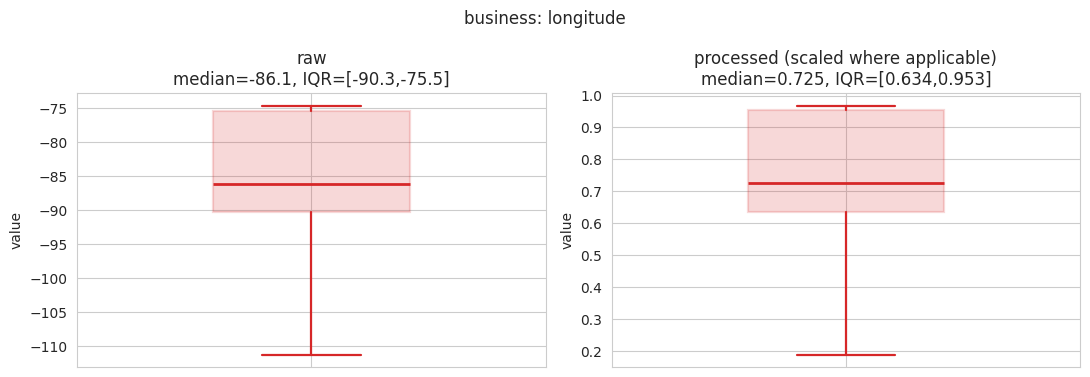

**Figure 2.14** — `business`.`stars` — boxplot summary (raw left, processed right)

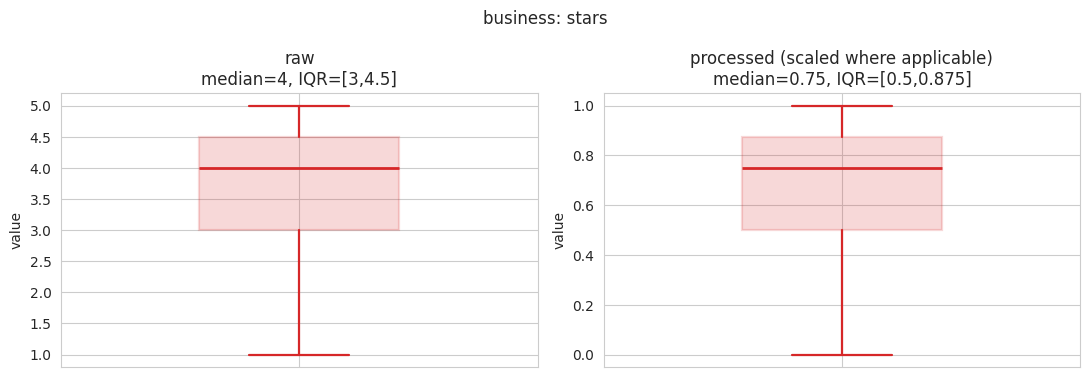

#### `review` — 3 numeric column(s) in both raw and processed

**Figure 2.15** — `review`.`cool` — boxplot summary (raw left, processed right)

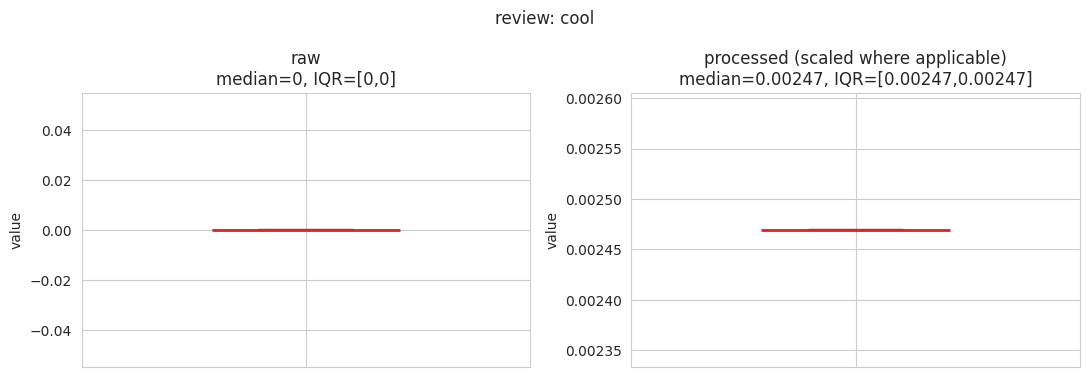

**Figure 2.16** — `review`.`useful` — boxplot summary (raw left, processed right)

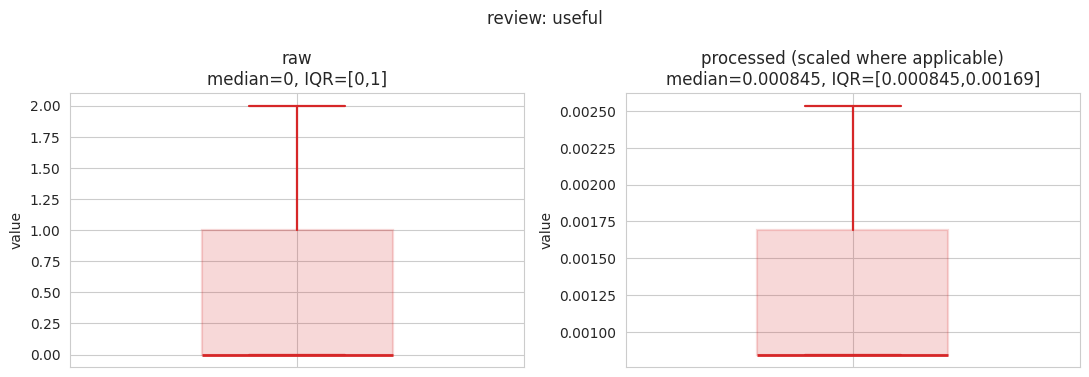

#### `user` — 17 numeric column(s) in both raw and processed

**Figure 2.17** — `user`.`average_stars` — boxplot summary (raw left, processed right)

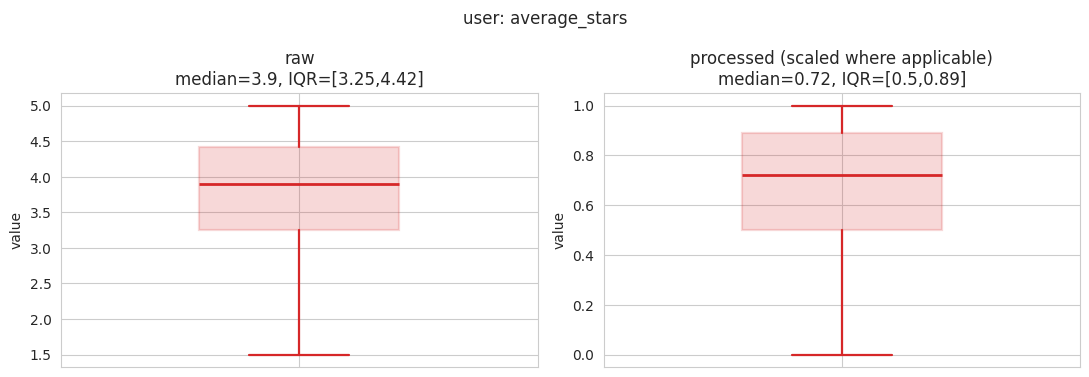

**Figure 2.18** — `user`.`compliment_cute` — boxplot summary (raw left, processed right)

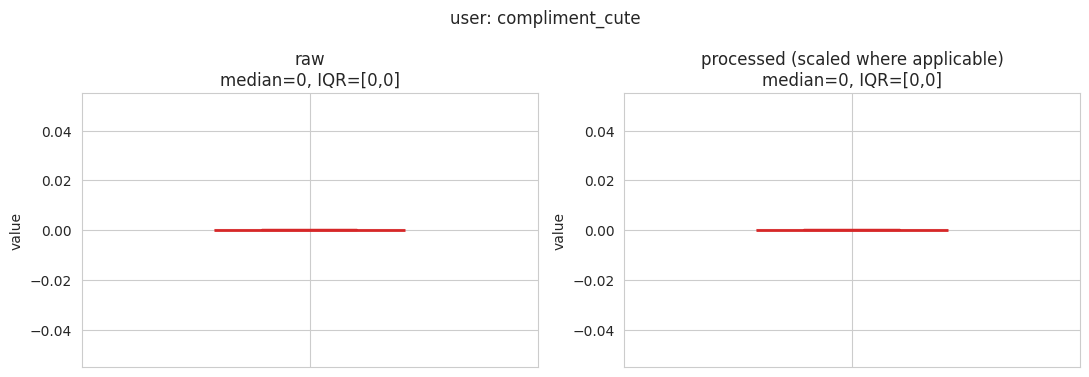

**Figure 2.19** — `user`.`compliment_hot` — boxplot summary (raw left, processed right)

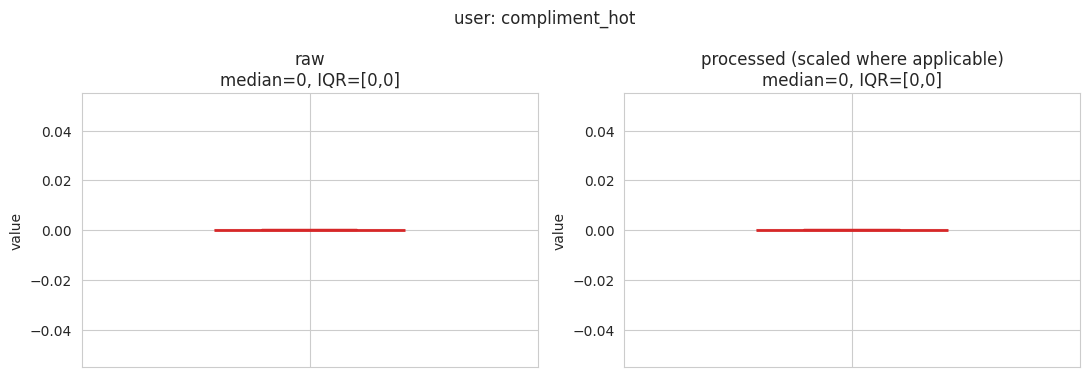

**Figure 2.20** — `user`.`compliment_more` — boxplot summary (raw left, processed right)

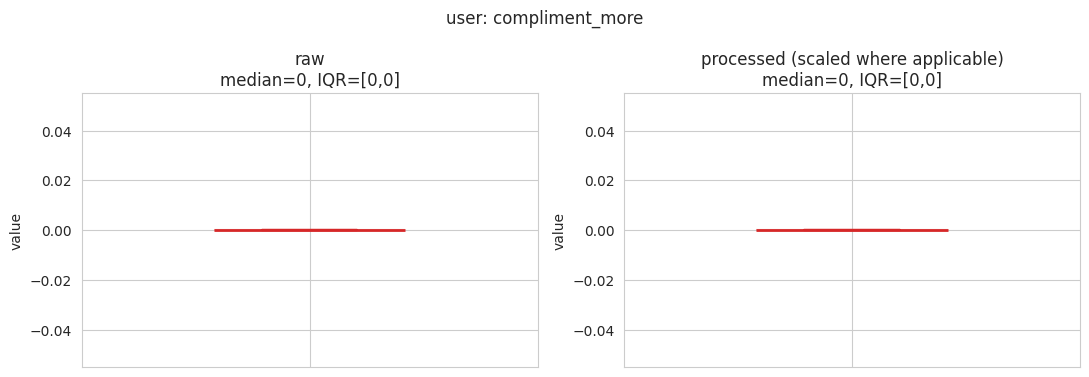

**Figure 2.21** — `user`.`compliment_photos` — boxplot summary (raw left, processed right)

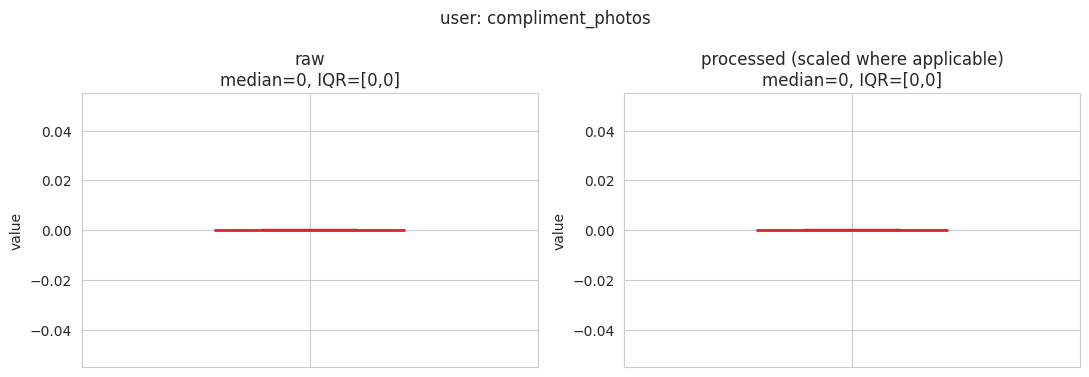

**Figure 2.22** — `user`.`compliment_profile` — boxplot summary (raw left, processed right)

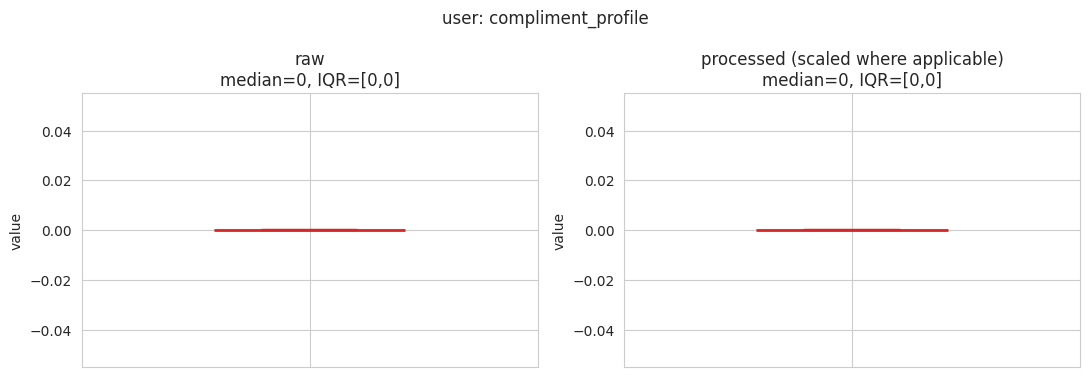

**Figure 2.23** — `user`.`cool` — boxplot summary (raw left, processed right)

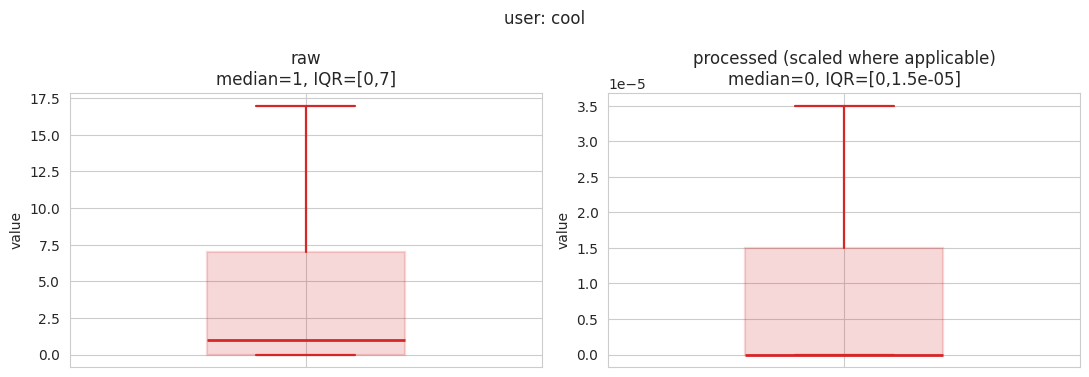

**Figure 2.24** — `user`.`funny` — boxplot summary (raw left, processed right)

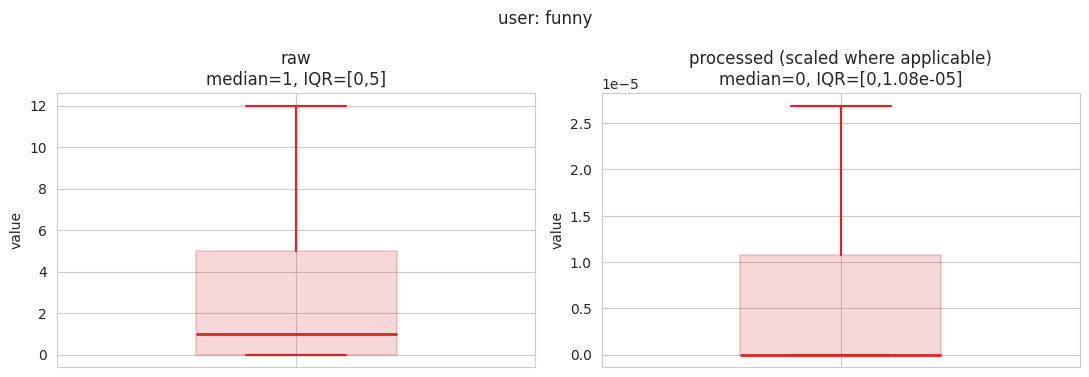

**Figure 2.25** — `user`.`useful` — boxplot summary (raw left, processed right)

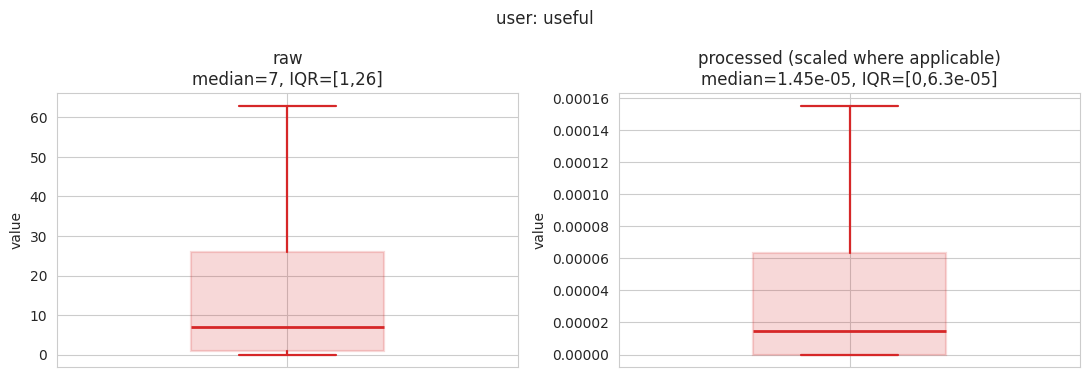

#### `checkin` — 0 numeric column(s) in both raw and processed

#### `tip` — 1 numeric column(s) in both raw and processed

#### `photo` — 0 numeric column(s) in both raw and processed

In [61]:
import numpy as np


def _degenerate_series(s) -> bool:
    s = pd.Series(s).dropna()
    if len(s) <= 1:
        return True
    return bool(s.nunique() <= 1)


def _plot_axis_dist(ax, s, title: str, *, max_bar_levels: int = 30) -> None:
    s = pd.Series(s).dropna()
    if len(s) == 0:
        ax.text(
            0.5,
            0.5,
            f"{title}\n(no data)",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        return
    q1, med, q3 = np.quantile(s, [0.25, 0.5, 0.75])
    bp = ax.boxplot(
        [s],
        vert=True,
        showfliers=False,
        widths=0.42,
        patch_artist=True,
    )
    medians = bp.get("medians") or []
    # Force consistent red styling (user request: yellow -> red).
    color = "#d62728"
    
    # Make the box/IQR rectangle visible (not just thin lines).
    for box in bp.get("boxes", []):
        box.set_facecolor(color)
        box.set_alpha(0.18)
        box.set_edgecolor(color)
        box.set_linewidth(1.6)

    for median in medians:
        median.set_color(color)
        median.set_linewidth(2.0)

    for whisker in bp.get("whiskers", []):
        whisker.set_color(color)
        whisker.set_linewidth(1.6)

    for cap in bp.get("caps", []):
        cap.set_color(color)
        cap.set_linewidth(1.6)
    ax.set_xticks([1])
    ax.set_xticklabels([""], fontsize=8)
    ax.set_ylabel("value")
    ax.set_title(f"{title}\nmedian={med:.3g}, IQR=[{q1:.3g},{q3:.3g}]")
    return
    nu = int(s.nunique())
    if nu <= max_bar_levels:
        vc = s.value_counts().sort_index()
        vc.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black", width=0.85)
        ax.set_xticklabels([str(x)[:14] for x in vc.index], rotation=45, ha="right")
        ax.set_ylabel("count")
    else:
        nb = min(40, max(10, int(np.sqrt(len(s)))))
        s.hist(ax=ax, bins=nb, edgecolor="black", alpha=0.75, color="steelblue")
        ax.set_ylabel("frequency")
    ax.set_title(title)


# Sampling per table (single-column selects; tune if runtime is high)
PLOT_FRAC = {
    "business": 0.12,
    "review": 0.05,
    "user": 0.08,
    "checkin": 0.28,
    "tip": 0.12,
    "photo": 0.35,
}

TABLE_ORDER = ["business", "review", "user", "checkin", "tip", "photo"]
fig_num = 12

for name in TABLE_ORDER:
    if name not in raw or name not in processed:
        continue
    rdf, pdf = raw[name], processed[name]
    paired = sorted(set(numeric_columns(rdf)) & set(numeric_columns(pdf)))
    frac = PLOT_FRAC.get(name, 0.15)
    display(
        Markdown(
            f"#### `{name}` — {len(paired)} numeric column(s) in both raw and processed"
        )
    )
    for col_idx, col in enumerate(paired):
        if col_idx % 2 == 1:
            continue
        pr = to_pandas_sample(rdf.select(col), fraction=frac, columns=[col])
        pp = to_pandas_sample(pdf.select(col), fraction=frac, columns=[col])
        pr_s = pd.Series(pr[col]).dropna()
        pp_s = pd.Series(pp[col]).dropna()

        def _is_booleanish(x: pd.Series) -> bool:
            if len(x) == 0:
                return False
            v = x.to_numpy(dtype=float)
            r = np.round(v)
            # tolerate tiny floating errors
            return bool(np.all((np.abs(v - r) <= 1e-6) & ((r == 0) | (r == 1))))

        # Skip booleans and other low-cardinality “class numerics”.
        if _is_booleanish(pr_s) or _is_booleanish(pp_s):
            continue
        max_classes = 6
        if max(int(pr_s.nunique()), int(pp_s.nunique())) <= max_classes:
            continue
        if _degenerate_series(pr[col]) and _degenerate_series(pp[col]):
            continue
        fig_num += 1
        display(
            Markdown(
                f"**Figure 2.{fig_num}** — `{name}`.`{col}` — boxplot summary (raw left, processed right)"
            )
        )
        fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11, 3.8))
        fig.suptitle(f"{name}: {col}")
        _plot_axis_dist(ax_l, pr[col], "raw")
        _plot_axis_dist(ax_r, pp[col], "processed (scaled where applicable)")
        plt.tight_layout()
        plt.show()


In [62]:
lin = read_column_lineage()
if lin:
    for name in sorted(lin.keys()):
        du = lin[name].get("dropped_uninformative_columns") or []
        print(f"{name}: dropped uninformative ({len(du)}): {', '.join(du) if du else '(none)'}")
else:
    print("No column_lineage.json — run run_preprocessing.ipynb through Stage 7 first.")


business: dropped uninformative (2): attr_AcceptCreditCards, category_count
checkin: dropped uninformative (0): (none)
photo: dropped uninformative (0): (none)
review: dropped uninformative (1): stars
tip: dropped uninformative (0): (none)
user: dropped uninformative (3): elite_count, friend_count, is_elite


<!-- removed: section explained later -->


<!-- removed: duplicates/nulls EDA section explained later -->


---
## Pipeline overview (matches `run_preprocessing.ipynb`)

| Stage | Step | Role |
|-------|------|------|
| 1 | Load | Read JSON into Spark |
| 2 | Clean | Nulls, duplicates |
| 3 | Flatten | Nested maps/arrays → columns |
| 4 | Prune | Drop redundant nested fields after flatten |
| 4b | Uninformative screen | Drop all-null or constant columns (see lineage) |
| 5 | Transform | Parse dates, min–max scale numerics, drop raw `date` strings |
| 6 | Reduce | Optional sampling (default: none) |
| 7 | Write | Parquet + `column_lineage.json` under `artifacts/processed/` |


---
## Stage 1 — Load

JSON datasets read into Spark (`load_dataset`). Row/column volumes are summarized after processing in Stages 3–4.


---
## Stage 2 — Clean

Imputation and duplicate drops on primary keys. Row counts change only when cleaning removes rows.


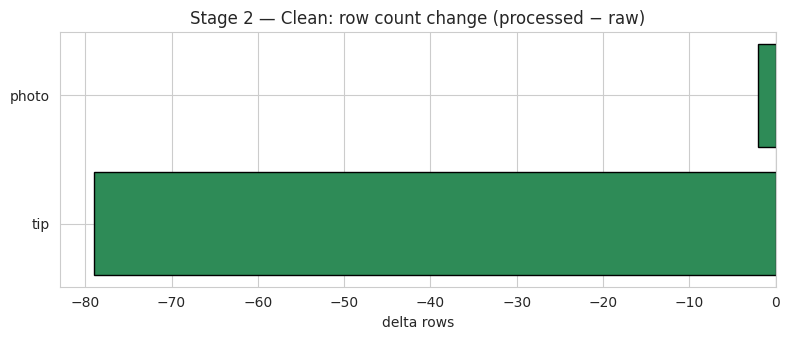

In [63]:
# Build impact_df (needed for Clean plot below and for column/row charts in Stages 3–4)
impact_rows = []
for name in TABLE_NAMES:
    if name not in raw or name not in processed:
        continue
    impact_rows.append(
        {
            "table": name,
            "raw_cols": len(raw[name].columns),
            "proc_cols": len(processed[name].columns),
            "raw_rows": raw[name].count(),
            "proc_rows": processed[name].count(),
        }
    )
impact_df = pd.DataFrame(impact_rows)
impact_df["delta_cols"] = impact_df["proc_cols"] - impact_df["raw_cols"]
impact_df["delta_rows"] = impact_df["proc_rows"] - impact_df["raw_rows"]
# Stage 2 — Clean: row deltas (tips lose duplicate keys, etc.)
fig, ax = plt.subplots(figsize=(8, 3.5))
d = impact_df[impact_df["delta_rows"] != 0].copy()
if len(d):
    ax.barh(d["table"], d["delta_rows"], color="seagreen", edgecolor="black")
    ax.set_title("Stage 2 — Clean: row count change (processed − raw)")
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.set_xlabel("delta rows")
else:
    ax.text(0.5, 0.5, "No row-count change between raw load and processed Parquet.", ha="center", va="center")
    ax.set_axis_off()
plt.tight_layout()
plt.show()


---
<a id="stage-3--flatten"></a>
## Stage 3 — Flatten

Lineage table, **full schema inventory** (raw vs processed columns, removals, lineage prune/add lists), plotting helpers, **schema-width** bars, then flatten-specific bars and processed distributions.


#### Lineage snapshot (`column_lineage.json`)

Written by `run_preprocessing.ipynb` Stage 7. Counts below feed the flatten/prune bar charts in this section and in Stage 4.


In [64]:
lineage = read_column_lineage()
if lineage is None:
    print("No column_lineage.json — run run_preprocessing.ipynb (through Stage 7) to write it.")
else:
    rows = []
    for name in sorted(lineage.keys()):
        info = lineage[name]
        rows.append(
            {
                "table": name,
                "after_clean": info["column_count_after_clean"],
                "after_flatten": info["column_count_after_flatten"],
                "flatten_added_n": len(info.get("flatten_added_columns") or []),
                "pruned_n": len(info.get("pruned_columns") or []),
                "after_screen": info.get(
                    "column_count_after_screen", info["column_count_after_prune"]
                ),
                "dropped_uninf_n": len(info.get("dropped_uninformative_columns") or []),
                "final": info["column_count_final"],
            }
        )
    print(pd.DataFrame(rows).to_string(index=False))


   table  after_clean  after_flatten  flatten_added_n  pruned_n  after_screen  dropped_uninf_n  final
business           14             56               42         3            51                2     51
 checkin            2              3                1         0             3                0      6
   photo            4              4                0         0             4                0      4
  review            9              9                0         0             8                1     11
     tip            5              5                0         0             5                0      8
    user           22             25                3         2            20                3     24


#### Schema inventory (Stages 3–4)

Use this to **audit** raw vs processed Parquet and what the pipeline **pruned**, **flatten-added**, or **dropped at transform**.

- **Full detail** is written to **`artifacts/processed/schema_inventory.txt`** (next to Parquet) so long output is not cut off in the notebook.
- Below prints a **one-line summary per table** only.
- **No duplicate lists:** we print *pruned*, *flatten-added*, and *transform/other drops* once each (lineage); those replace separate “removed vs added” blocks that repeated the same names.


In [65]:
# Schema inventory: full column lists + pipeline changes (Stages 3–4)
# Full text → artifacts/processed/schema_inventory.txt (avoids notebook truncation).

sections: list[str] = []

for name in TABLE_NAMES:
    if name not in raw or name not in processed:
        sections.append(
            f"{'=' * 72}\n{name}\n{'=' * 72}\n(skip: missing raw or processed)\n"
        )
        continue
    rcols = sorted(raw[name].columns)
    pcols = sorted(processed[name].columns)
    removed = sorted(set(rcols) - set(pcols))

    sec: list[str] = []
    sec.append("=" * 72)
    sec.append(name)
    sec.append("=" * 72)
    sec.append(f"Raw columns ({len(rcols)}): {', '.join(rcols)}")
    sec.append("")
    sec.append(f"Processed columns ({len(pcols)}): {', '.join(pcols)}")
    sec.append("")

    if lineage and name in lineage:
        info = lineage[name]
        pr = sorted(info.get("pruned_columns") or [])
        fa = sorted(info.get("flatten_added_columns") or [])
        pr_set = set(pr)
        transform_or_other = sorted(set(removed) - pr_set)
        sec.append("--- Pipeline column changes (from lineage) ---")
        sec.append(f"Pruned after flatten ({len(pr)}): {', '.join(pr) if pr else '(none)'}")
        sec.append(f"Added by flatten ({len(fa)}): {', '.join(fa) if fa else '(none)'}")
        du = sorted(info.get("dropped_uninformative_columns") or [])
        dat = sorted(info.get("dropped_after_transform") or [])
        sec.append(f"Dropped uninformative — screen ({len(du)}): {', '.join(du) if du else '(none)'}")
        sec.append(f"Dropped after screen — transform ({len(dat)}): {', '.join(dat) if dat else '(none)'}")
        sec.append(
            "Dropped after prune — raw-vs-processed diff (legacy) "
            f"({len(transform_or_other)}): "
            f"{', '.join(transform_or_other) if transform_or_other else '(none)'}"
        )
    else:
        added = sorted(set(pcols) - set(rcols))
        sec.append("--- Column changes (set diff; lineage not loaded) ---")
        sec.append(f"Removed from raw schema ({len(removed)}): {', '.join(removed) if removed else '(none)'}")
        sec.append(f"Added in processed ({len(added)}): {', '.join(added) if added else '(none)'}")

    sections.append("\n".join(sec))

report = "\n\n".join(sections)
out_path = PROCESSED_DIR / "schema_inventory.txt"
out_path.write_text(report + "\n", encoding="utf-8")

print("Schema inventory — summary (full lists in file):\n")
for name in TABLE_NAMES:
    if name not in raw or name not in processed:
        print(f"  {name}: missing raw or processed")
        continue
    nr, np_ = len(raw[name].columns), len(processed[name].columns)
    if lineage and name in lineage:
        info = lineage[name]
        pr = info.get("pruned_columns") or []
        fa = info.get("flatten_added_columns") or []
        rem = sorted(set(raw[name].columns) - set(processed[name].columns))
        otr = len(set(rem) - set(pr))
        du_n = len(info.get('dropped_uninformative_columns') or [])
        print(
            f"  {name}: raw={nr} cols, processed={np_} cols | "
            f"pruned={len(pr)}, flatten_added={len(fa)}, uninformative={du_n}, transform/other={otr}"
        )
    else:
        print(f"  {name}: raw={nr} cols, processed={np_} cols (no lineage)")

print(f"\nFull column lists → {out_path.resolve()}")


Schema inventory — summary (full lists in file):

  business: raw=14 cols, processed=51 cols | pruned=3, flatten_added=42, uninformative=2, transform/other=0
  review: raw=9 cols, processed=11 cols | pruned=0, flatten_added=0, uninformative=1, transform/other=2
  user: raw=22 cols, processed=24 cols | pruned=2, flatten_added=3, uninformative=3, transform/other=0
  checkin: raw=2 cols, processed=6 cols | pruned=0, flatten_added=1, uninformative=0, transform/other=1
  tip: raw=5 cols, processed=8 cols | pruned=0, flatten_added=0, uninformative=0, transform/other=1
  photo: raw=4 cols, processed=4 cols | pruned=0, flatten_added=0, uninformative=0, transform/other=0

Full column lists → /home/dash/University/term-6/big-data/yelp-spark-project/artifacts/processed/schema_inventory.txt


In [66]:
import numpy as np


def degenerate_series(s) -> bool:
    """True if a histogram would collapse to a single bin."""
    s = pd.Series(s).dropna()
    if len(s) <= 1:
        return True
    return bool(s.nunique() <= 1)


def plot_hist_grid(pdf, cols, title, bins=35, max_cols=3):
    """Multi-panel histograms; skips degenerate columns."""
    cols = [c for c in cols if c in pdf.columns]
    usable = [c for c in cols if not degenerate_series(pdf[c])]
    skipped = [c for c in cols if c not in usable]
    if skipped:
        print(f"{title}: skipped degenerate columns: {skipped}")
    if not usable:
        print(f"{title}: no plottable columns (all degenerate or missing).")
        return
    n = len(usable)
    ncols = min(max_cols, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for i, col in enumerate(usable):
        pdf[col].dropna().hist(ax=axes[i], bins=bins, edgecolor="black", alpha=0.75, color="steelblue")
        axes[i].set_title(col)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_ax_feature_dist(ax, s, title: str, max_bar_levels=30):
    """Bar chart of value counts when cardinality is low, else histogram (avoids empty panels after min–max scaling)."""
    s = pd.Series(s).dropna()
    if len(s) == 0:
        ax.text(0.5, 0.5, f"{title}\n(no data)", ha="center", va="center", transform=ax.transAxes)
        return
    nu = int(s.nunique())
    if nu <= max_bar_levels:
        vc = s.value_counts().sort_index()
        vc.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black", width=0.85)
        ax.set_xticklabels([str(x)[:14] for x in vc.index], rotation=45, ha="right")
        ax.set_ylabel("count")
    else:
        s.hist(ax=ax, bins=min(40, max(10, int(np.sqrt(len(s))))), edgecolor="black", alpha=0.75, color="steelblue")
        ax.set_ylabel("frequency")
    ax.set_title(title)


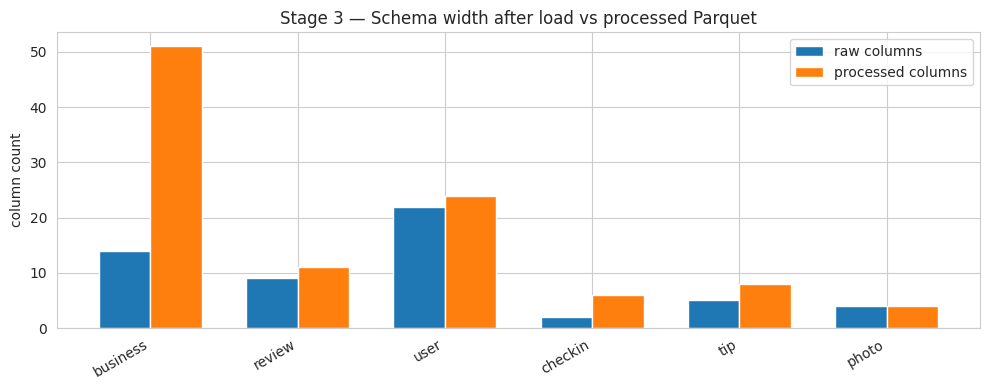

   table  raw_cols  proc_cols  delta_cols
business        14         51          37
  review         9         11           2
    user        22         24           2
 checkin         2          6           4
     tip         5          8           3
   photo         4          4           0


In [67]:
# Schema width: raw vs processed columns (same data as former “Pipeline impact”, left panel)
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(impact_df))
w = 0.35
ax.bar(x - w / 2, impact_df["raw_cols"], w, label="raw columns", color="tab:blue")
ax.bar(x + w / 2, impact_df["proc_cols"], w, label="processed columns", color="tab:orange")
ax.set_xticks(x)
ax.set_xticklabels(impact_df["table"], rotation=30, ha="right")
ax.set_ylabel("column count")
ax.legend()
ax.set_title("Stage 3 — Schema width after load vs processed Parquet")
plt.tight_layout()
plt.show()
print(impact_df[["table", "raw_cols", "proc_cols", "delta_cols"]].to_string(index=False))


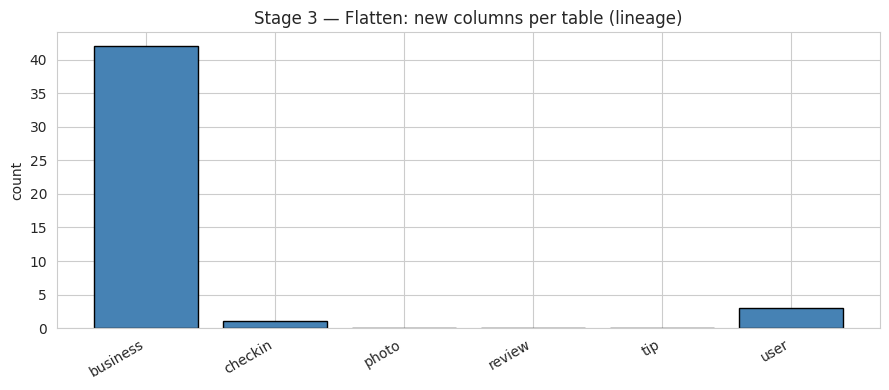

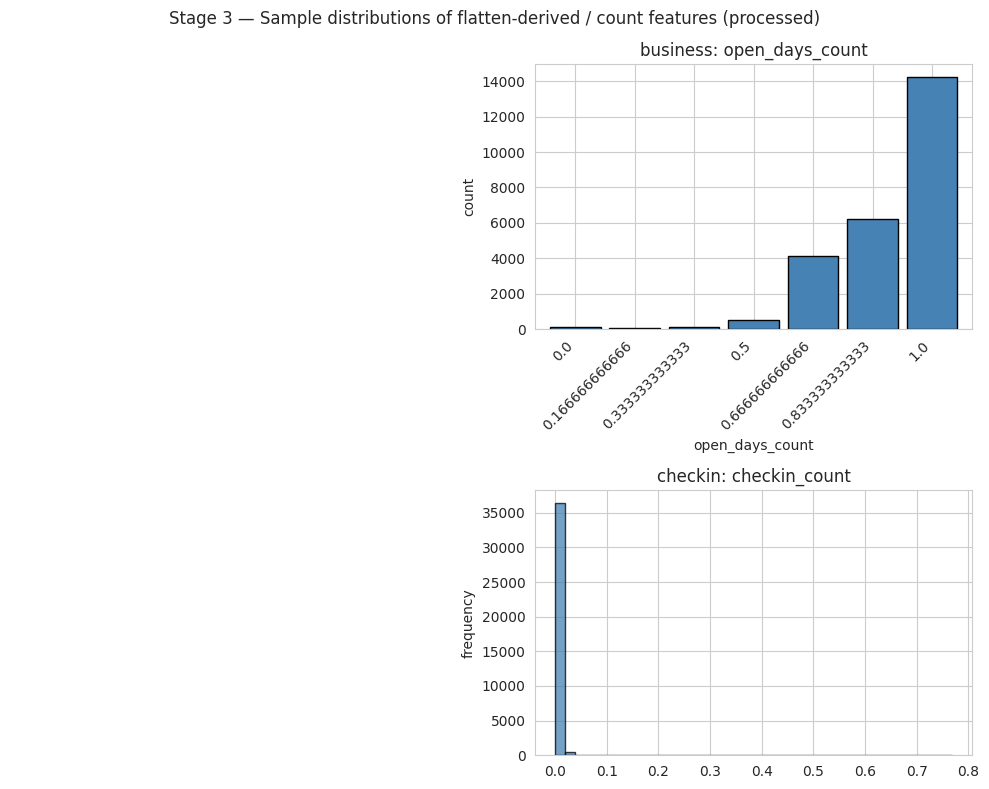

In [68]:
# Stage 3 — Flatten: bar chart + enriched feature distributions (processed Parquet)
if lineage:
    names = sorted(lineage.keys())
    vals = [len(lineage[n]["flatten_added_columns"]) for n in names]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(names, vals, color="steelblue", edgecolor="black")
    ax.set_title("Stage 3 — Flatten: new columns per table (lineage)")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Stage 3 — Sample distributions of flatten-derived / count features (processed)")
specs = [
    ("business", "category_count", 0.22),
    ("business", "open_days_count", 0.2),
    ("user", "friend_count", 0.18),
    ("checkin", "checkin_count", 0.28),
]
for ax, (t, col, frac) in zip(np.array(axes).flat, specs):
    if t not in processed or col not in processed[t].columns:
        ax.set_axis_off()
        continue
    pdf = to_pandas_sample(processed[t].select(col), fraction=frac, columns=[col])
    plot_ax_feature_dist(ax, pdf[col], f"{t}: {col}")
plt.tight_layout()
plt.show()


---
<a id="stage-4--prune"></a>
## Stage 4 — Prune

**Row-volume** bars, then **prune** bar (columns dropped per table). Column lists and what was already pruned are in **Schema inventory** above (same lineage as here).


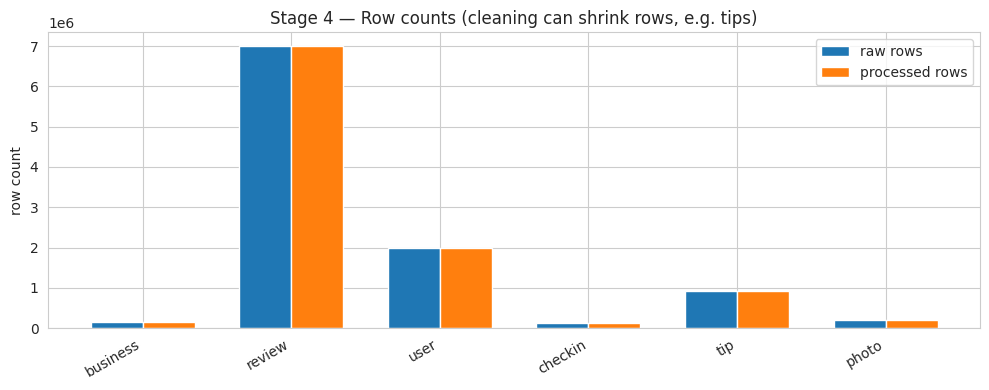

   table  raw_rows  proc_rows  delta_rows
business    150346     150346           0
  review   6990280    6990280           0
    user   1987897    1987897           0
 checkin    131930     131930           0
     tip    908915     908836         -79
   photo    200100     200098          -2


In [69]:
# Row volume: raw vs processed (same data as former “Pipeline impact”, right panel)
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(impact_df))
w = 0.35
ax.bar(x - w / 2, impact_df["raw_rows"], w, label="raw rows", color="tab:blue")
ax.bar(x + w / 2, impact_df["proc_rows"], w, label="processed rows", color="tab:orange")
ax.set_xticks(x)
ax.set_xticklabels(impact_df["table"], rotation=30, ha="right")
ax.set_ylabel("row count")
ax.legend()
ax.set_title("Stage 4 — Row counts (cleaning can shrink rows, e.g. tips)")
plt.tight_layout()
plt.show()
print(impact_df[["table", "raw_rows", "proc_rows", "delta_rows"]].to_string(index=False))


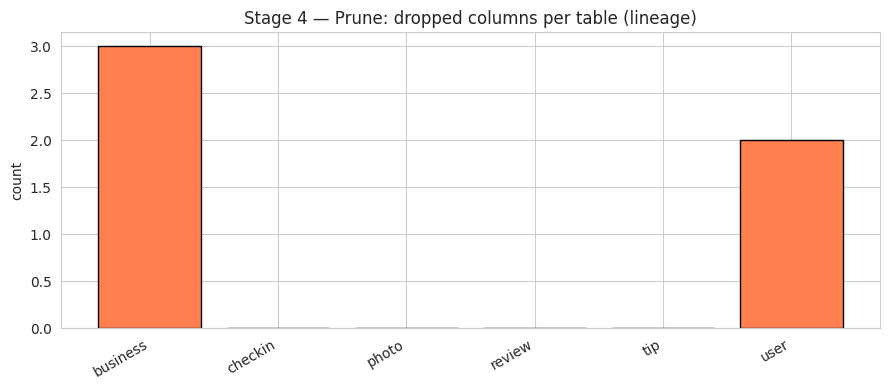

In [70]:
# Stage 4 — Prune: columns removed per table (lineage)
if lineage:
    names = sorted(lineage.keys())
    vals = [len(lineage[n]["pruned_columns"]) for n in names]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(names, vals, color="coral", edgecolor="black")
    ax.set_title("Stage 4 — Prune: dropped columns per table (lineage)")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()


---
## Stage 5 — Transform

Parse dates (`date_parsed`, `date_year`, …). **Min–max** scaling replaces original numerics in place ([`scale_numeric`](../../preprocessing/transform.py)). Below: **one figure per metric** with **raw** (left) and **processed** (right); review/tip also show **year from the raw date string** vs **`date_year`**.


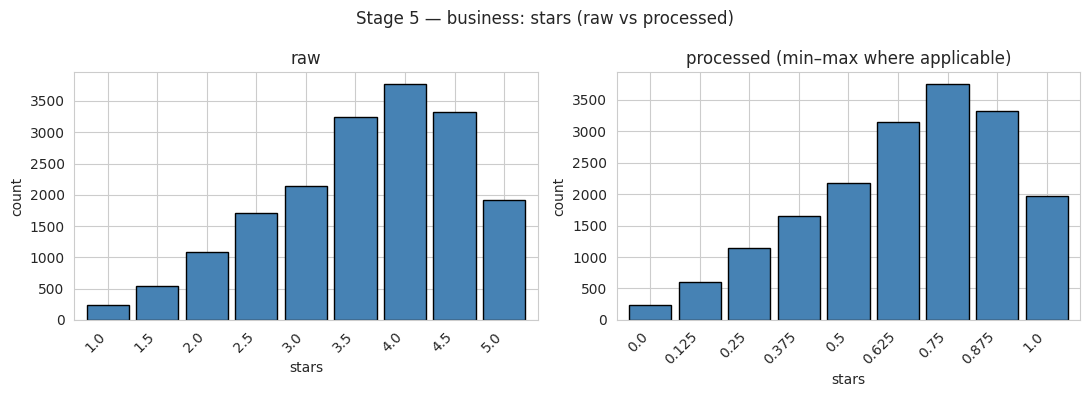

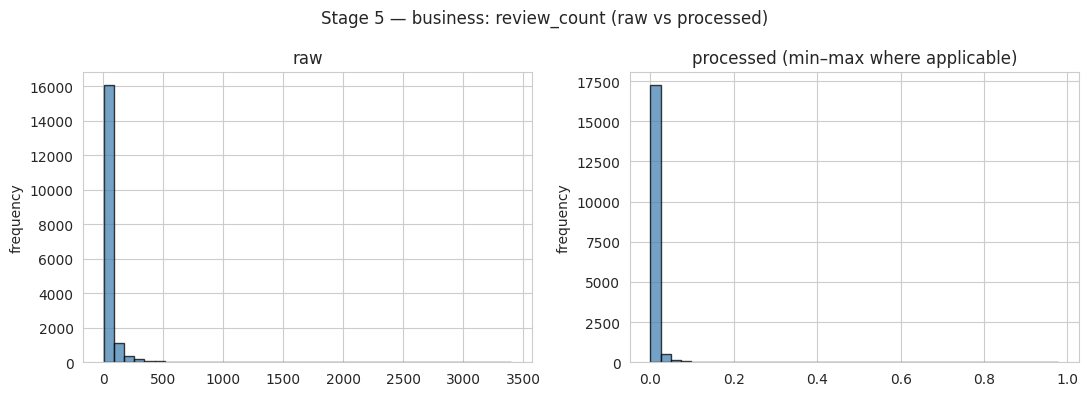

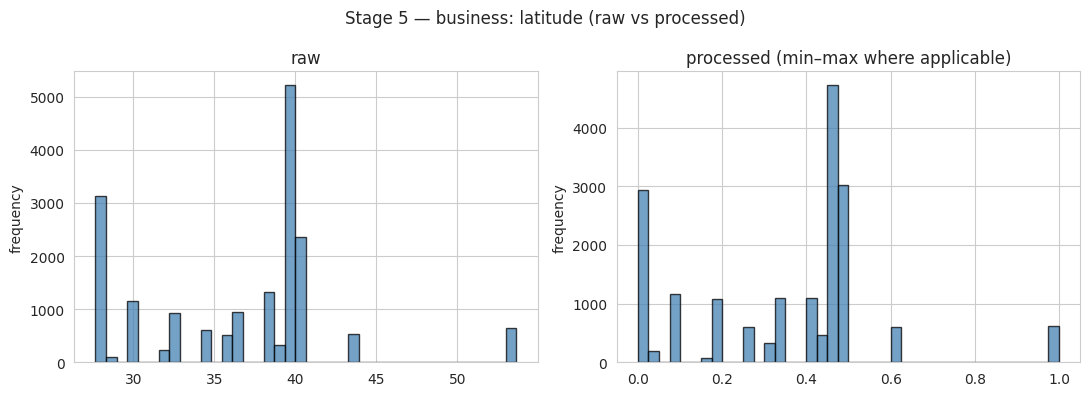

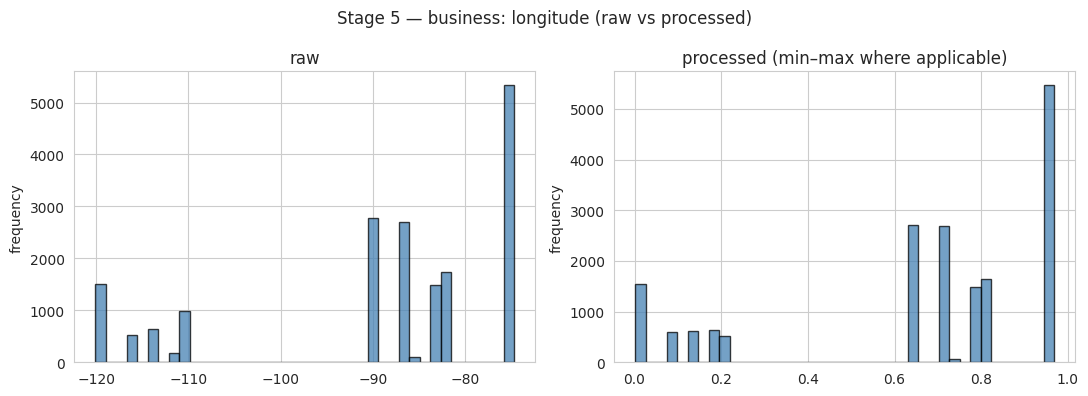

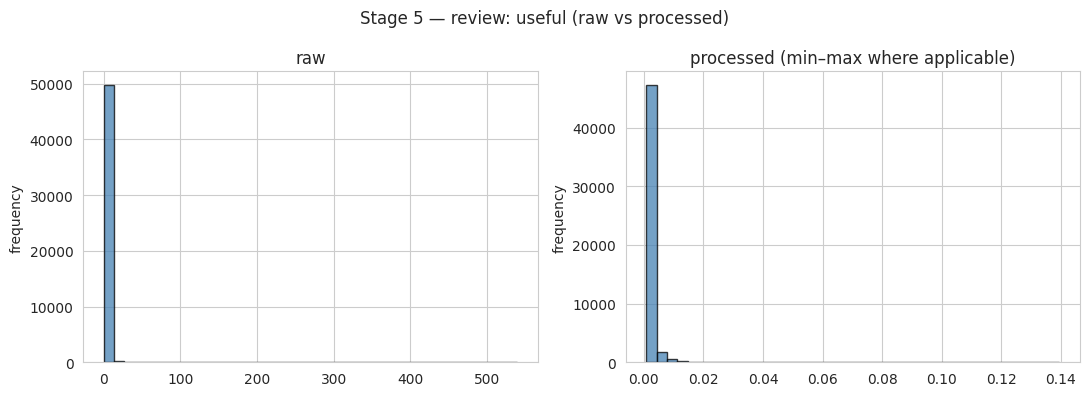

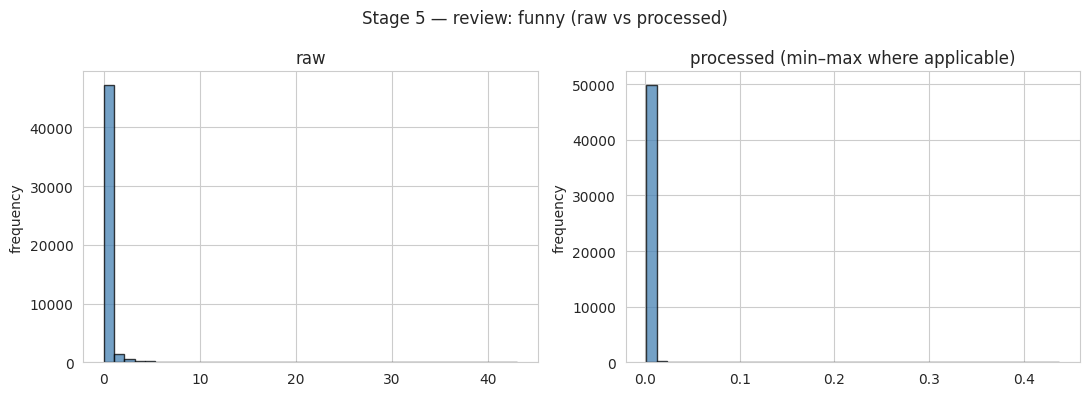

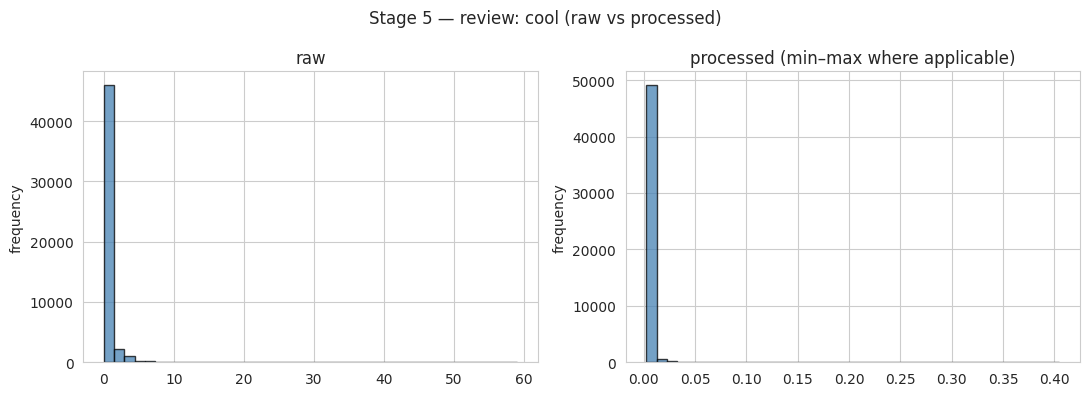

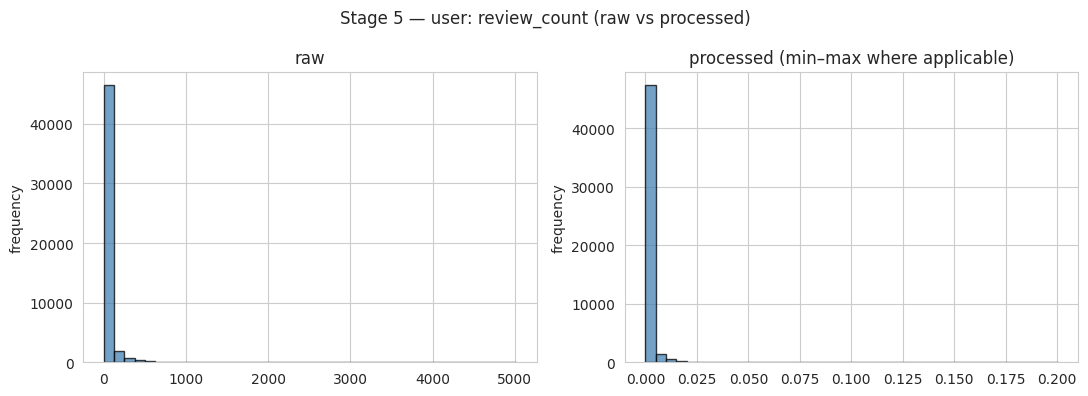

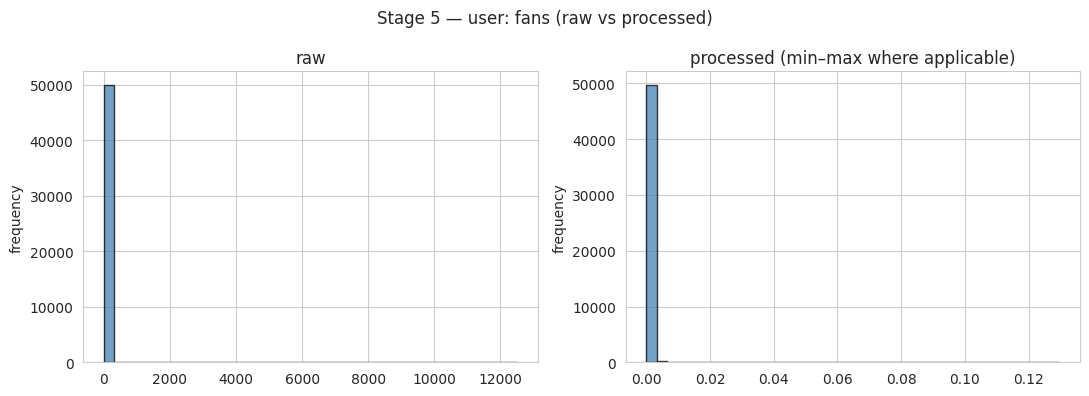

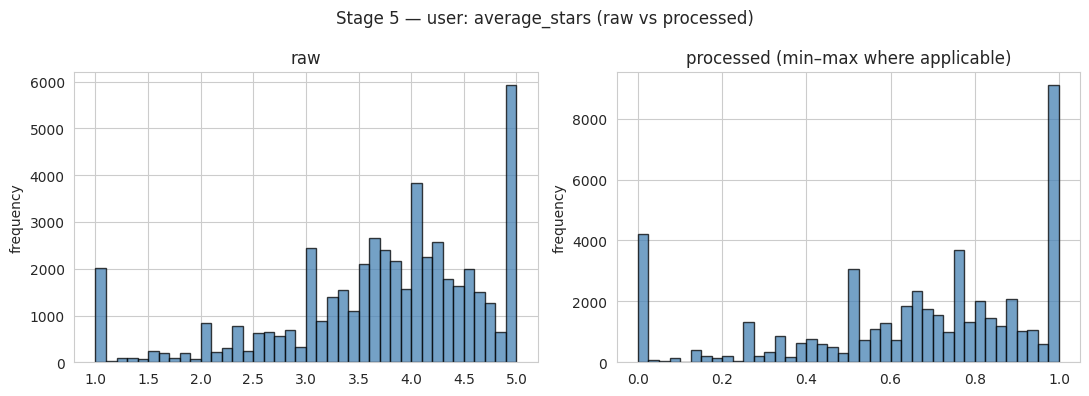

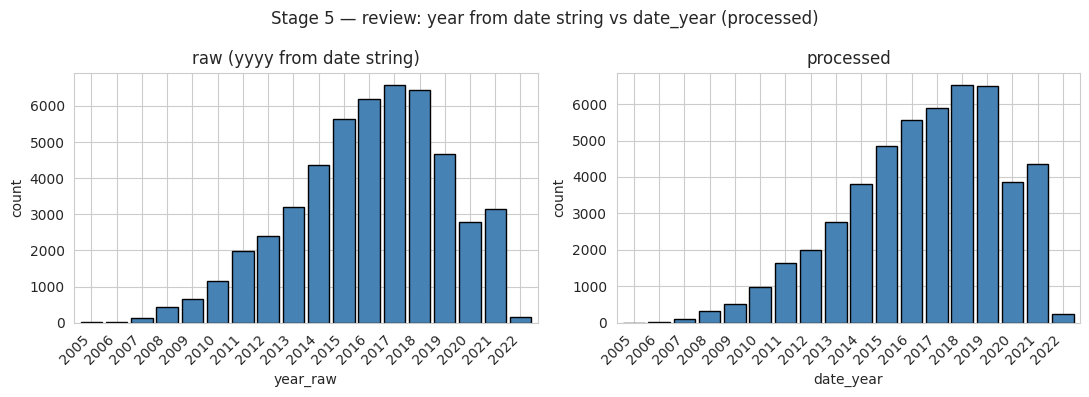

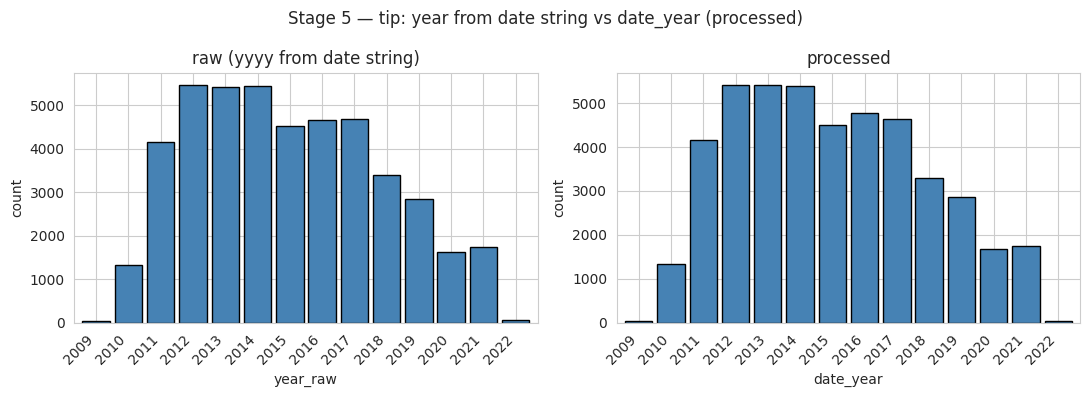

In [71]:
# Stage 5 — Transform: one figure per metric (raw left, processed right)
from pyspark.sql import functions as F


def _paired_raw_proc(rdf, pdf, table: str, cols: list[str], frac: float):
    for col in cols:
        if col not in rdf.columns or col not in pdf.columns:
            continue
        pr = to_pandas_sample(rdf.select(col), fraction=frac, columns=[col])
        pp = to_pandas_sample(pdf.select(col), fraction=frac, columns=[col])
        fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11, 4))
        fig.suptitle(f"Stage 5 — {table}: {col} (raw vs processed)")
        plot_ax_feature_dist(ax_l, pr[col], "raw")
        plot_ax_feature_dist(ax_r, pp[col], "processed (min–max where applicable)")
        plt.tight_layout()
        plt.show()


cols_b = [c for c in ["stars", "review_count", "latitude", "longitude"] if c in raw["business"].columns and c in processed["business"].columns]
_paired_raw_proc(raw["business"], processed["business"], "business", cols_b, 0.12)

cols_r = [c for c in ["stars", "useful", "funny", "cool"] if c in raw["review"].columns and c in processed["review"].columns]
_paired_raw_proc(raw["review"], processed["review"], "review", cols_r, 0.04)

cols_u = [c for c in ["review_count", "fans", "average_stars"] if c in raw["user"].columns and c in processed["user"].columns]
_paired_raw_proc(raw["user"], processed["user"], "user", cols_u, 0.08)

# Parsed year: raw substring vs processed date_year (review / tip)
for tname in ["review", "tip"]:
    if tname not in raw or tname not in processed:
        continue
    if "date" not in raw[tname].columns or "date_year" not in processed[tname].columns:
        continue
    raw_y = raw[tname].select(F.substring(F.trim(F.col("date")), 1, 4).cast("int").alias("year_raw"))
    pr = to_pandas_sample(raw_y, fraction=0.05, columns=["year_raw"])
    pp = to_pandas_sample(processed[tname].select("date_year"), fraction=0.05, columns=["date_year"])
    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11, 4))
    fig.suptitle(f"Stage 5 — {tname}: year from date string vs date_year (processed)")
    plot_ax_feature_dist(ax_l, pr["year_raw"], "raw (yyyy from date string)")
    plot_ax_feature_dist(ax_r, pp["date_year"], "processed")
    plt.tight_layout()
    plt.show()


---
## Stage 6 — Reduce

Default [`sample_fraction`](../../preprocessing/config.py) is `None` — no downsampling unless you configure it.


---
## Stage 7 — Write

Outputs: Parquet under `artifacts/processed/<table>/` and `artifacts/processed/column_lineage.json` (same folder as in `src.constants.PROCESSED_DIR`).


---
## Run summary



In [72]:
print("Run summary (rows × columns):")
for name in TABLE_NAMES:
    if name in raw and name in processed:
        r, p = raw[name].count(), processed[name].count()
        cr, cp = len(raw[name].columns), len(processed[name].columns)
        print(f"  {name}: rows {r} -> {p}, columns {cr} -> {cp}")


Run summary (rows × columns):
  business: rows 150346 -> 150346, columns 14 -> 51


  review: rows 6990280 -> 6990280, columns 9 -> 11


  user: rows 1987897 -> 1987897, columns 22 -> 24
  checkin: rows 131930 -> 131930, columns 2 -> 6
  tip: rows 908915 -> 908836, columns 5 -> 8
  photo: rows 200100 -> 200098, columns 4 -> 4
